In [1]:
import torch
print("PyTorch version " + torch.__version__)
# Detectar y inicializar GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Running on CPU")

# Importaciones de PyTorch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Importación de la clase WaveletDenoising
!pip install PyWavelets
import pywt

# Importación de librerías necesarias
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import signal
import h5py
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Configuraciones globales para visualización
plt.style.use('seaborn-v0_8-whitegrid')

PyTorch version 2.8.0+cu126
Running on GPU: Tesla T4


In [2]:
# Para montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Directory: /content/drive/MyDrive/Dataset/Looped
Sample Rate: 25600 Hz
Classification Mode: five_classes
Number of signals (training, testing): (960, 240)
Number of labels (training, testing): (960, 240)
Number of samples per signal: 25600


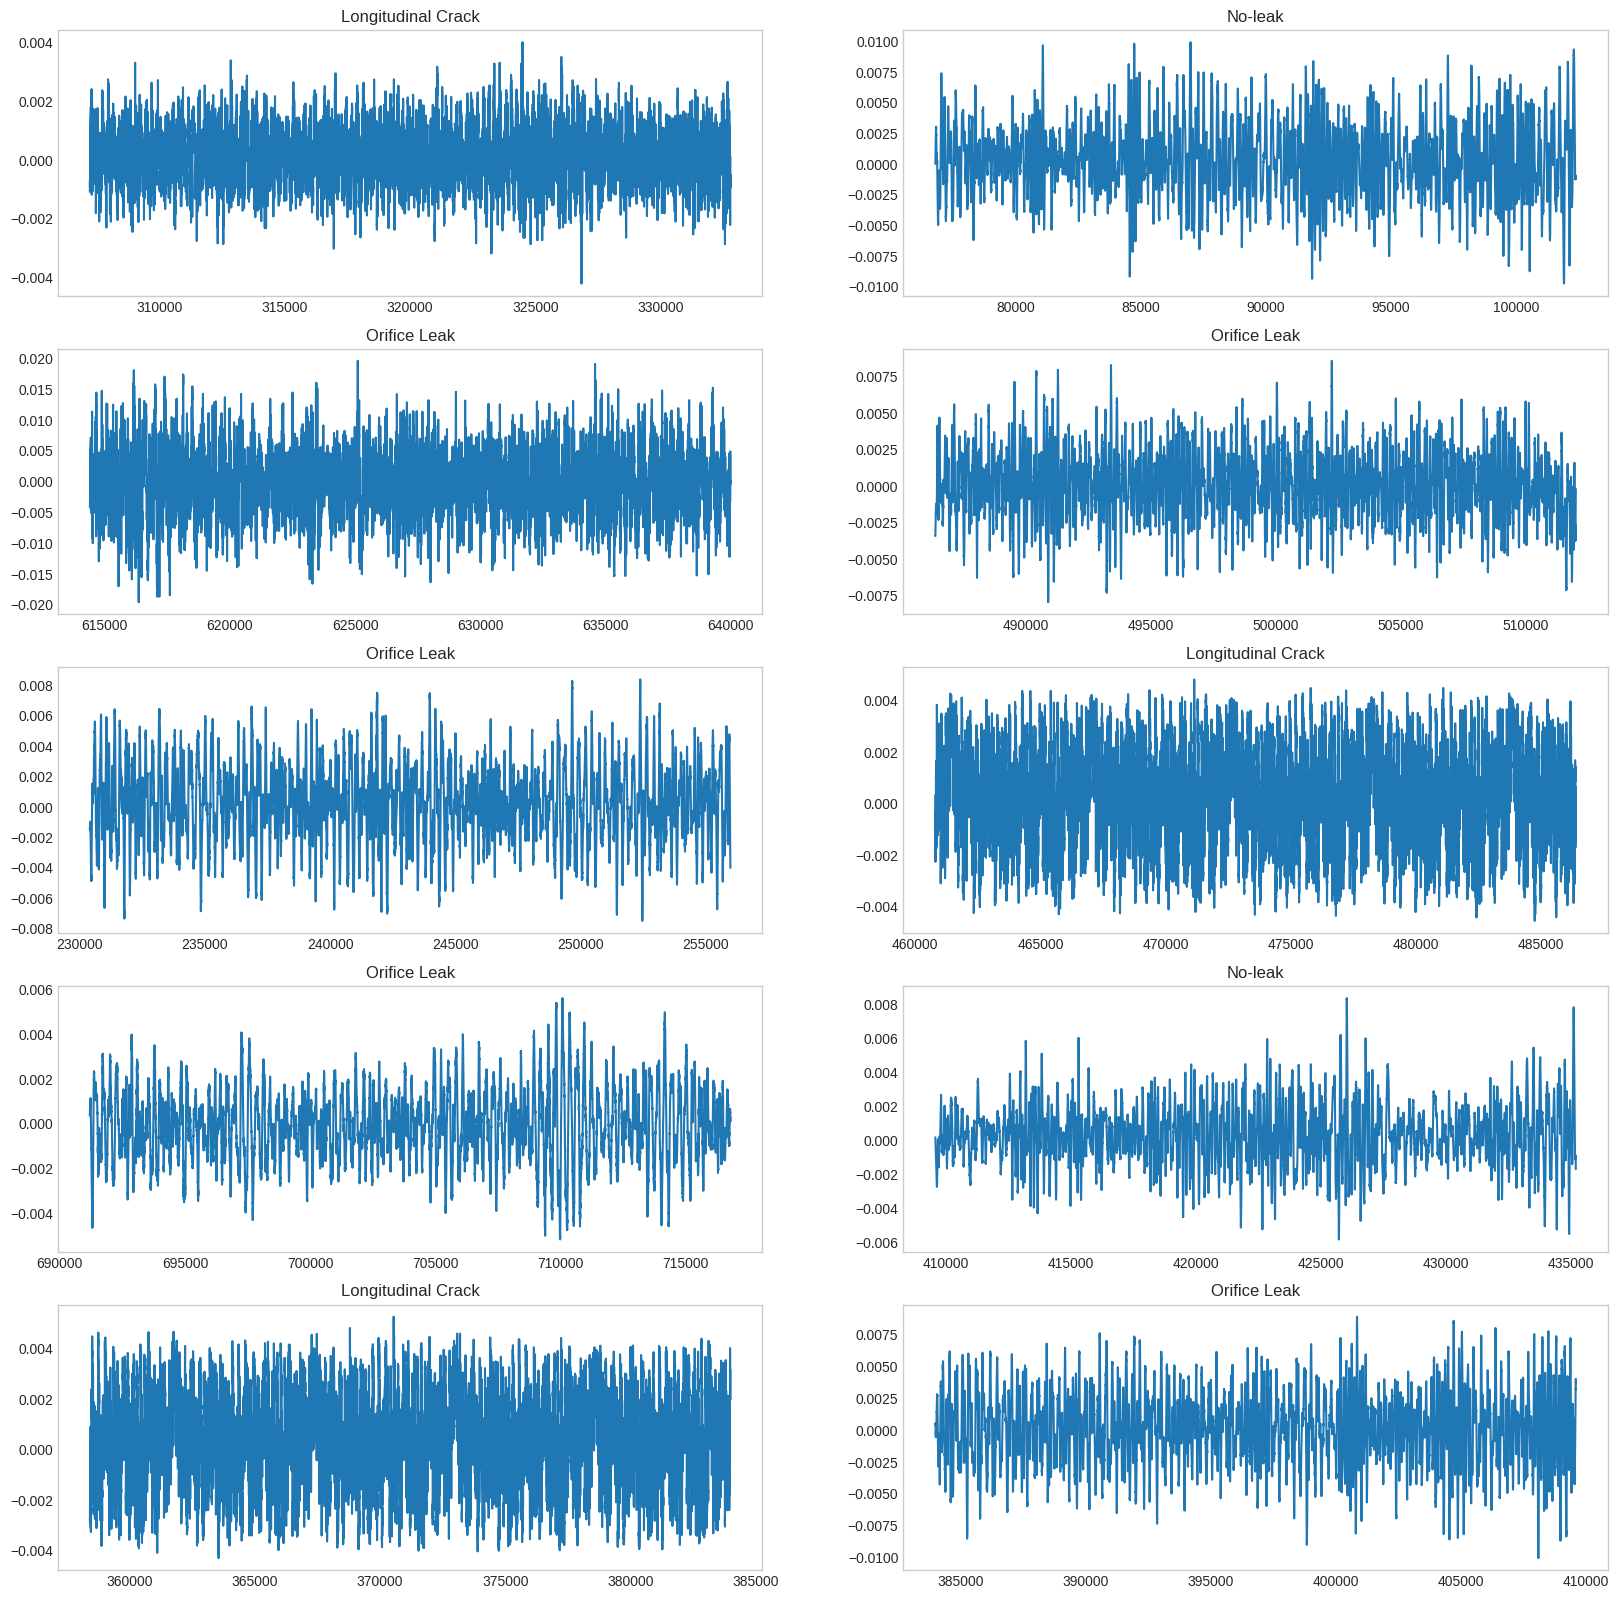

In [3]:
# Definir la ruta de los datos en Google Drive
data_dir = '/content/drive/MyDrive/Dataset/Looped'
original_sr = 25600 # Frecuencia de muestreo original en Hz
signal_sr = 25600 # Frecuencia de muestreo deseada en Hz
downsample_factor = original_sr // signal_sr

# Modo de clasificación: 'five_classes' o 'binary'
classification_mode = 'five_classes' # Cambiar según necesidad

# Diccionario de etiquetas según el modo de clasificación
if classification_mode == 'five_classes':
    label_codes_dict = {
        'Circumferential Crack': 0,
        'Gasket Leak': 1,
        'Longitudinal Crack': 2,
        'No-leak': 3,
        'Orifice Leak': 4
    }
else: # binary
    label_codes_dict = {'Leak': 0, 'No-leak': 1}

# Función para eliminar archivos .DS_Store si existen
def remove_DS_store_file(path):
    for ds_name in ['.DS_Store', '.DS_store']:
        ds_store_file_location = os.path.join(path, ds_name)
        if os.path.isfile(ds_store_file_location):
            os.remove(ds_store_file_location)

def load_accelerometer_data(data_dir, sample_rate, downsample_factor, label_codes, mode='five_classes', fraction_to_include=1):
    remove_DS_store_file(data_dir)
    signals = []
    labels = []

    # Para submuestreo en modo binario
    if mode == 'binary':
        # Diccionario para rastrear señales por tipo de fuga
        leak_type_signals = {
            'Circumferential Crack': [],
            'Gasket Leak': [],
            'Longitudinal Crack': [],
            'Orifice Leak': []
        }
        no_leak_signals = []
        sample_labels = [] # Para almacenar etiquetas originales (para estratificación)

    for label in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            print(f"Omitiendo {label_dir} porque no es un directorio")
            continue

        remove_DS_store_file(label_dir)

        for file in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file)
            if not os.path.isfile(file_path):
                continue

            accelerometer_signal_df = pd.read_csv(file_path, index_col=False)
            accelerometer_signal_df = accelerometer_signal_df.iloc[::downsample_factor, :].reset_index(drop=True)
            accelerometer_signal = accelerometer_signal_df['Value'][0:(sample_rate * 30)]

            sample_indexes = np.linspace(0, len(accelerometer_signal) - sample_rate, len(accelerometer_signal) // sample_rate)
            signal_frames_number = fraction_to_include * len(sample_indexes)
            signal_frames_counter = 0

            for signal_frame in sample_indexes:
                accelerometer_signal_frame = accelerometer_signal[int(signal_frame):int(signal_frame + sample_rate)]
                signal_frames_counter += 1

                if signal_frames_counter > signal_frames_number:
                    break

                if len(accelerometer_signal_frame) != sample_rate:
                    continue

                if mode == 'five_classes':
                    signals.append(accelerometer_signal_frame)
                    labels.append(label_codes[label])
                else: # binary
                    # En vez de añadir directamente, almacenamos por tipo de fuga
                    if label == 'No-leak':
                        no_leak_signals.append(accelerometer_signal_frame)
                        sample_labels.append('No-leak')
                    else:
                        # Almacenar en el diccionario correspondiente
                        leak_type_signals[label].append(accelerometer_signal_frame)
                        sample_labels.append(label)

    # Para modo binario, realizar submuestreo equilibrado
    if mode == 'binary':
        # Número total de muestras No-leak
        total_no_leak = len(no_leak_signals)

        # Calcular cuántas muestras tomar de cada tipo de fuga para balancear con No-leak
        samples_per_leak_type = total_no_leak // 4 # Dividir entre los 4 tipos de fuga

        # Si hay muy pocas muestras de algún tipo, ajustar todas para mantener la proporcionalidad
        min_available = min([len(leak_signals) for leak_signals in leak_type_signals.values()])
        if min_available < samples_per_leak_type:
            samples_per_leak_type = min_available

        # Limitar cada tipo de fuga a la cantidad calculada para balanceo
        balanced_leak_signals = []
        balanced_labels = []
        balanced_stratify = []

        # Añadir todas las muestras No-leak
        for signal in no_leak_signals:
            balanced_leak_signals.append(signal)
            balanced_labels.append(1) # No-leak
            balanced_stratify.append('No-leak')

        # Añadir cantidades equilibradas de cada tipo de fuga
        for leak_type, leak_signals in leak_type_signals.items():
            # Tomar exactamente samples_per_leak_type muestras de cada tipo de fuga
            for signal in leak_signals[:samples_per_leak_type]:
                balanced_leak_signals.append(signal)
                balanced_labels.append(0) # Leak
                balanced_stratify.append(leak_type) # Guardar tipo original para estratificación

        print(f"Balanceo de clases aplicado:")
        print(f"- Muestras No-leak: {total_no_leak}")
        print(f"- Muestras Leak (total): {samples_per_leak_type * 4}")
        print(f"- Muestras por tipo de fuga: {samples_per_leak_type}")

        return balanced_leak_signals, balanced_labels, balanced_stratify

    return signals, labels, None # None para modo five_classes

# Cargar los datos con submuestreo equilibrado
signals_lst, labels_lst, stratify_labels = load_accelerometer_data(
    data_dir,
    signal_sr,
    downsample_factor,
    label_codes_dict,
    mode=classification_mode,
    fraction_to_include=1
)

# Dividir los datos en conjuntos de entrenamiento y prueba con estratificación
signals_dict = {'training': [], 'testing': []}
labels_dict = {'training': [], 'testing': []}

if stratify_labels:
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'], stratify_train, stratify_test = train_test_split(
        signals_lst,
        labels_lst,
        stratify_labels,
        test_size=0.2,
        random_state=53,
        stratify=stratify_labels
    )
else:
    # Para modo five_classes, usar las etiquetas para estratificar
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'] = train_test_split(
        signals_lst,
        labels_lst,
        test_size=0.2,
        random_state=53,
        stratify=labels_lst # Estratificar por las etiquetas directamente
    )

# Imprimir información sobre el dataset
print(f'Data Directory: {data_dir}')
print(f'Sample Rate: {signal_sr} Hz')
print(f'Classification Mode: {classification_mode}')
print(f'Number of signals (training, testing): ({len(signals_dict["training"])}, {len(signals_dict["testing"])})')
print(f'Number of labels (training, testing): ({len(labels_dict["training"])}, {len(labels_dict["testing"])})')
print(f'Number of samples per signal: {len(signals_dict["training"][0])}')


# Visualizar algunas señales
plt.figure(figsize=(20, 20))
rows, cols = 5, 2
n = rows * cols
random_index = []

for i in range(n):
    plt.subplot(rows, cols, i + 1)
    random_index.append(np.random.randint(0, len(signals_dict['training'])))
    plt.plot(signals_dict['training'][random_index[i]])

    if classification_mode == 'five_classes':
        label_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(labels_dict['training'][random_index[i]])]
    else:
        label_name = 'Leak' if labels_dict['training'][random_index[i]] == 0 else 'No-leak'

    plt.title(label_name)
    plt.grid()
plt.show()

In [4]:
# Modificación de la clase WaveletDenoising para especificar wavelet y nivel directamente
import tqdm
class WaveletDenoising:
    """Clase para denoising con wavelets con wavelet y nivel específicos."""

    def __init__(self, normalize=True, wavelet='db4', level=3, thr_mode='soft', method="universal"):
        """
        Inicializa el denoiser con parámetros específicos.

        Args:
            normalize: Si es True, normaliza la señal antes del denoising.
            wavelet: Wavelet a utilizar.
            level: Nivel de descomposición wavelet.
            thr_mode: Modo de umbralización ('soft' o 'hard').
            method: Método de umbralización ("universal" o "level_dependent").
        """
        self.normalize = normalize
        self.wavelet = wavelet
        self.level = level
        self.thr_mode = thr_mode
        self.method = method

    def fit(self, data):
        """Aplica el denoising a los datos de entrada."""
        # Convertir a array numpy
        data = np.asarray(data)

        # Normalizar si es necesario
        if self.normalize:
            data = (data - np.mean(data)) / (np.std(data) if np.std(data) != 0 else 1.0)

        # Descomponer con wavelet
        coeffs = pywt.wavedec(data, self.wavelet, level=self.level)

        # Umbral
        if self.method == "universal":
            sigma = self._estimate_sigma(coeffs[-1])
            threshold = sigma * np.sqrt(2 * np.log(len(data)))
        else:
            threshold = self._estimate_level_dependent_threshold(coeffs)

        # Aplicar umbral
        new_coeffs = []
        new_coeffs.append(coeffs[0]) # Aproximación
        for i in range(1, len(coeffs)):
            if self.thr_mode == 'soft':
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
            else:
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='hard'))

        # Reconstruir
        return pywt.waverec(new_coeffs, self.wavelet)

    def _estimate_sigma(self, detail_coeffs):
        """Estima la desviación estándar del ruido."""
        return np.median(np.abs(detail_coeffs)) / 0.6745

    def _estimate_level_dependent_threshold(self, coeffs):
        """Estima umbrales dependientes del nivel."""
        return np.std(coeffs[-1]) * 3.0

def apply_wavelet_denoising(signals_dict, wavelet, level):
    """
    Aplica denoising wavelet con una wavelet y nivel específicos.

    Args:
        signals_dict: Diccionario con señales de entrenamiento y prueba
        wavelet: Nombre de la wavelet a utilizar
        level: Nivel de descomposición

    Returns:
        wavelet_denoised_signals: Diccionario con señales procesadas
    """
    # Crear objeto WaveletDenoising con los parámetros especificados
    wd = WaveletDenoising(
        normalize=True,
        wavelet=wavelet,
        level=level,
        thr_mode='soft',
        method="universal"
    )

    # Crear diccionario para señales procesadas
    wavelet_denoised_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal_element in tqdm.tqdm(signals_subset, desc=f"Aplicando {wavelet} nivel {level} a {key}"):
            # Denoising de la señal
            try:
                denoised_signal = wd.fit(signal_element)
                wavelet_denoised_signals[key].append(denoised_signal)
            except Exception as e:
                print(f"Error al procesar señal con {wavelet} nivel {level}: {str(e)}")
                # En caso de error, usar la señal original
                wavelet_denoised_signals[key].append(signal_element)

    return wavelet_denoised_signals

wavelet_denoised_signals_dict=apply_wavelet_denoising(signals_dict, "db38", 4)

# Función para normalizar señales
def normalize_signals(signals_dict):
    """
    Normaliza cada señal del diccionario a un rango de 0 a 1.

    Args:
        signals_dict: Diccionario con señales a normalizar.

    Returns:
        normalized_signals: Diccionario con señales normalizadas.
    """
    normalized_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal in tqdm.tqdm(signals_subset, desc=f"Normalizando {key} signals"):
            min_val = np.min(signal)
            max_val = np.max(signal)

            if max_val > min_val:
                normalized_signal = (signal - min_val) / (max_val - min_val)
            else:
                normalized_signal = np.ones_like(signal) * 0.5

            normalized_signals[key].append(normalized_signal)

    return normalized_signals

wavelet_denoised_signals_dict=normalize_signals(wavelet_denoised_signals_dict)

Normalizando testing signals: 100%|██████████| 240/240 [00:00<00:00, 3794.31it/s]


Generating spectrograms for testing: 100%|██████████| 240/240 [00:00<00:00, 572.19it/s]


Number of spectrograms (training, testing): (960, 240)
Spectrogram shape: (257, 101)


<Figure size 2000x2200 with 0 Axes>

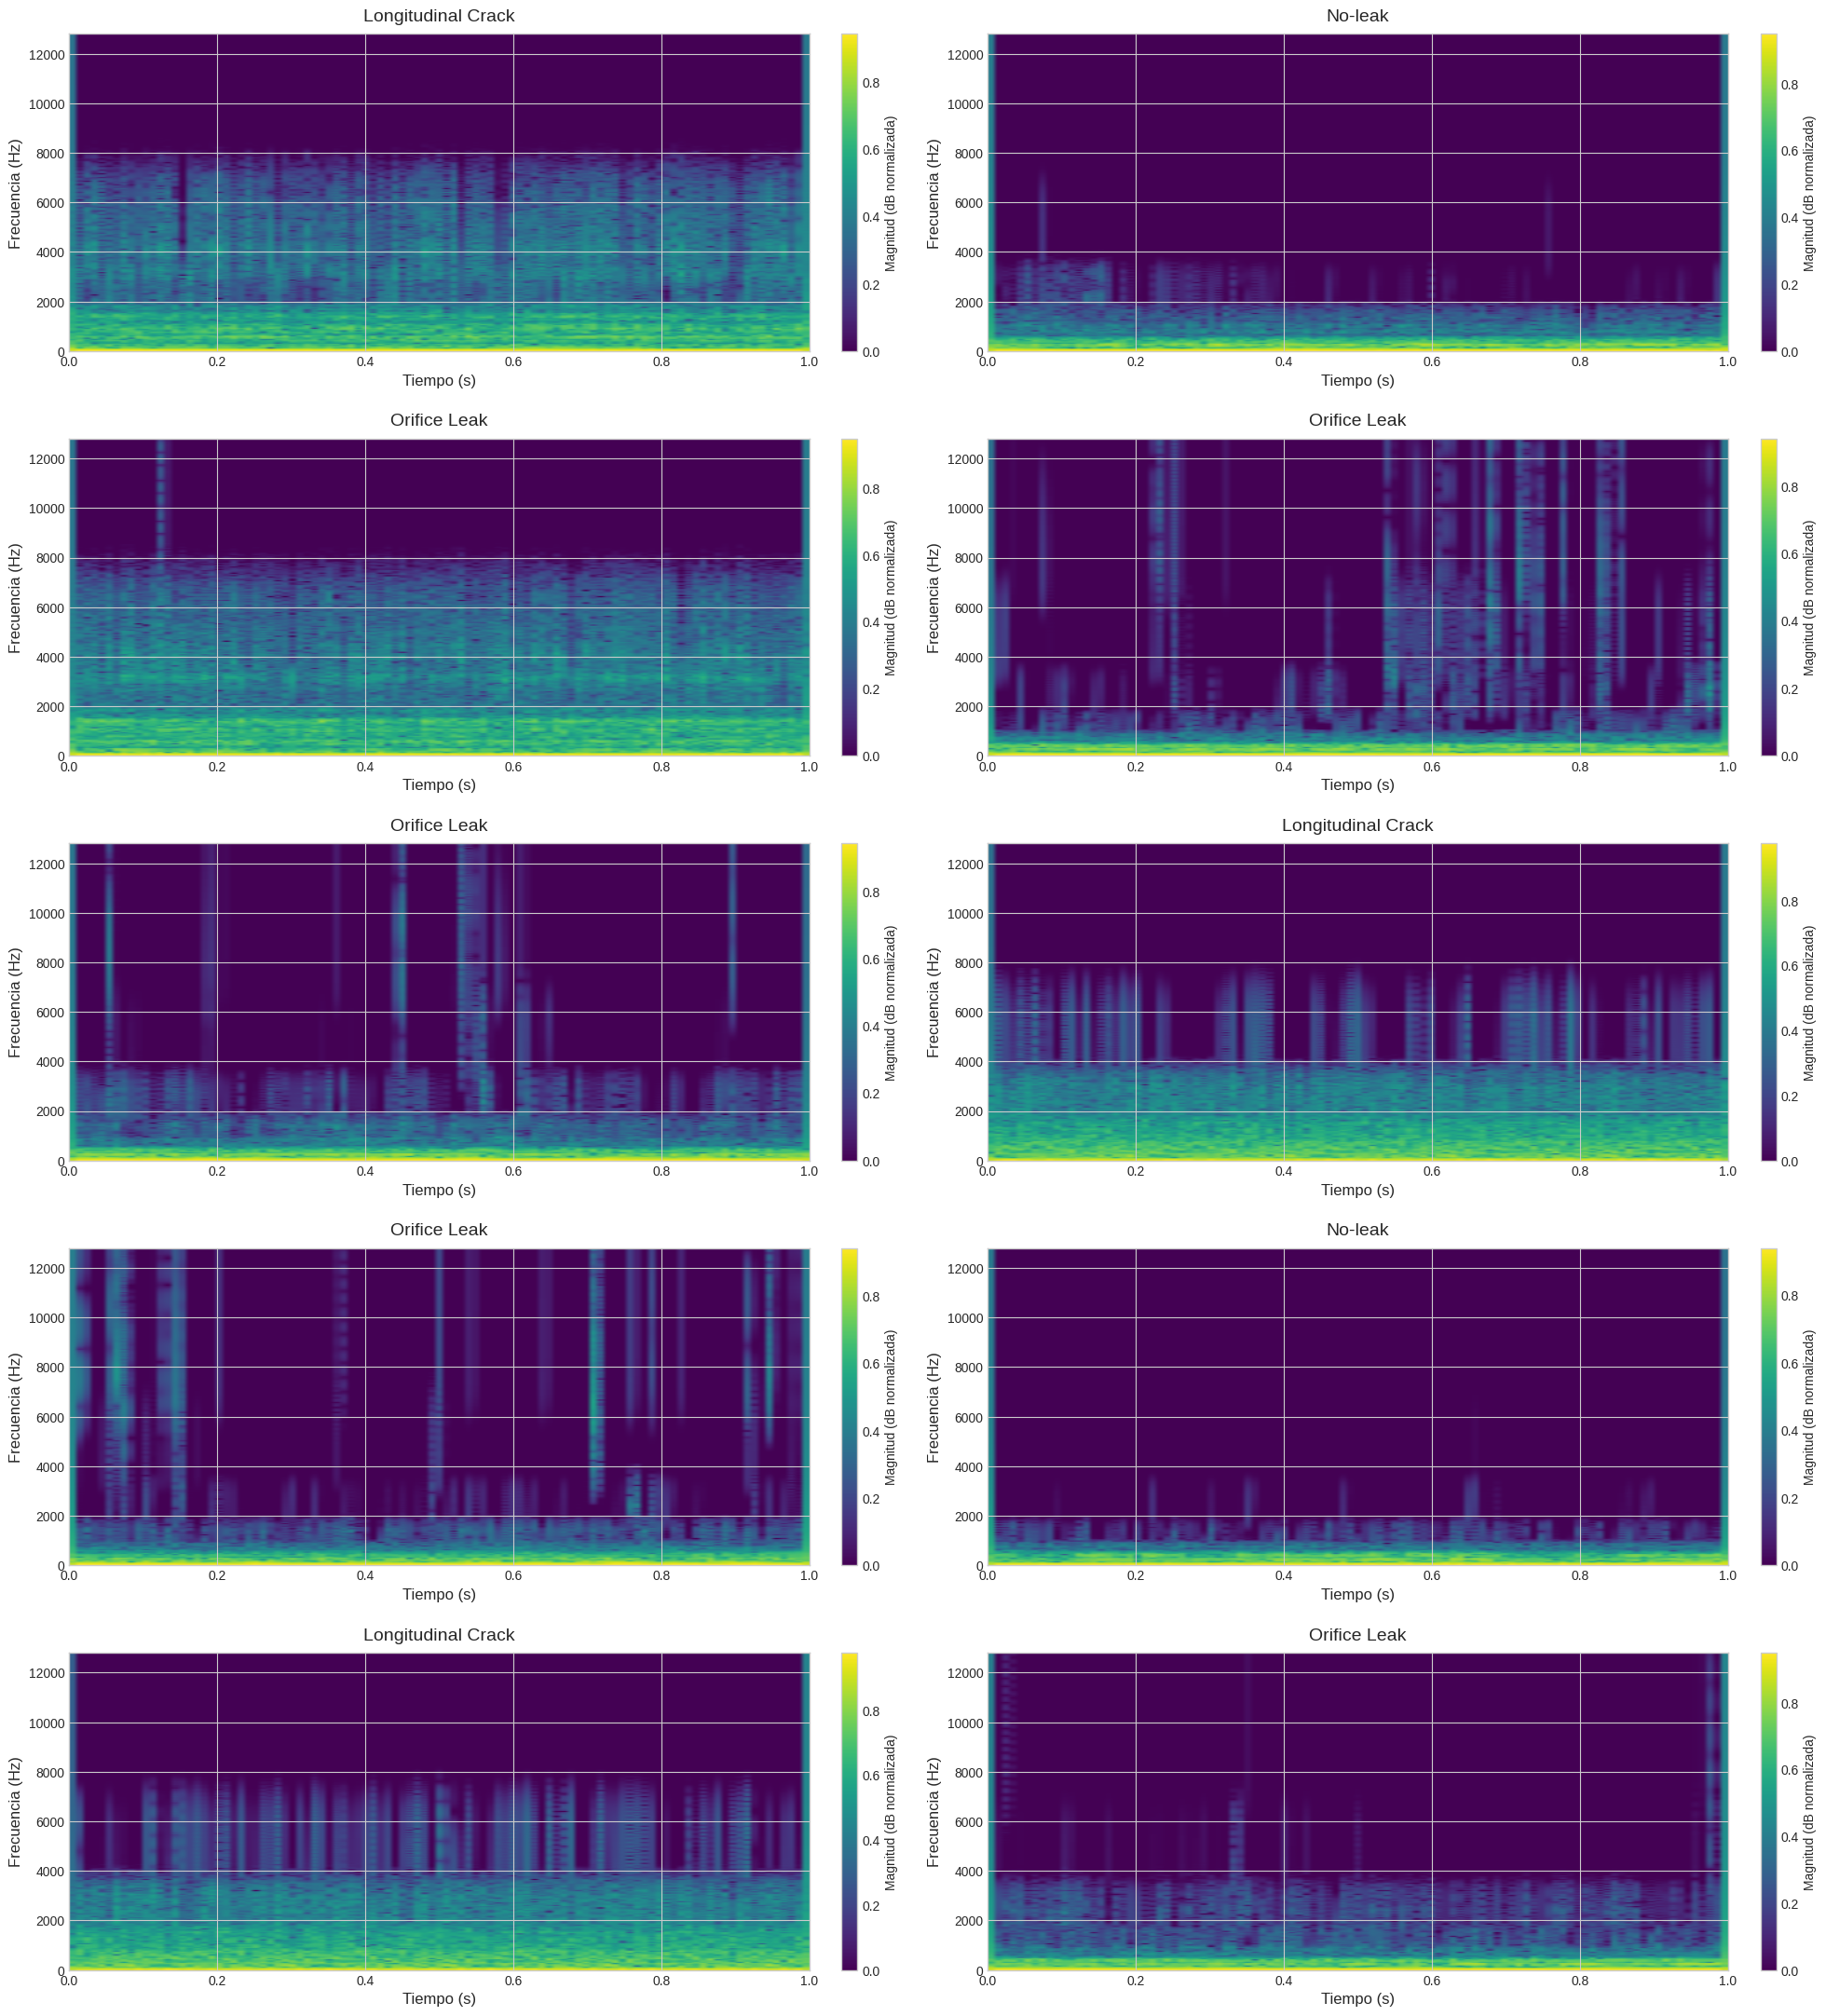

In [5]:
def generate_log_spectrograms(signals_dict, labels_dict, fs=25600):
    """
    Genera espectrogramas logarítmicos usando STFT

    Args:
        signals_dict: Diccionario con señales de entrenamiento y prueba
        labels_dict: Diccionario con etiquetas
        fs: Frecuencia de muestreo en Hz

    Returns:
        spectrograms_dict: Diccionario con espectrogramas
        labels_dict: Diccionario con etiquetas
    """
    # Parámetros para STFT adaptados a nuestra frecuencia de muestreo (25.6kHz vs 8kHz del paper)
    # Frame length: 20ms x 25.6kHz = 512 muestras
    # Frame shift: 10ms x 25.6kHz = 256 muestras
    frame_length = int(0.02 * fs) # 20 ms
    frame_shift = int(0.01 * fs) # 10 ms
    nfft = 512 # Tamaño de FFT como se especificó

    # Crear diccionario para almacenar espectrogramas
    spectrograms_dict = {'training': [], 'testing': []}

    # Verificar si es necesario eliminar frames con ruido de alta energía
    apply_denoising = False

    # Umbral para identificar frames con ruido (ajustar según sea necesario)
    mean_threshold = 0.7
    std_threshold = 0.5

    for key, signals_subset in signals_dict.items():
        for i, signal in enumerate(tqdm.tqdm(signals_subset, desc=f"Generating spectrograms for {key}")):
            # Aplicar STFT
            f, t, Zxx = scipy.signal.stft(
                signal,
                fs=fs,
                window='hann',
                nperseg=frame_length,
                noverlap=frame_length-frame_shift,
                nfft=nfft
            )

            # Calcular espectrograma de potencia (magnitud al cuadrado)
            power_spectrogram = np.abs(Zxx)**2

            if apply_denoising:
                # Identificar frames con ruido de alta energía
                frame_means = np.mean(power_spectrogram, axis=0)
                frame_stds = np.std(power_spectrogram, axis=0)

                # Normalizar para obtener valores relativos
                norm_means = frame_means / np.max(frame_means)
                norm_stds = frame_stds / np.max(frame_stds)

                # Identificar frames ruidosos que superan los umbrales
                noisy_frames = (norm_means > mean_threshold) | (norm_stds > std_threshold)

                # Procesar frames ruidosos
                for j, is_noisy in enumerate(noisy_frames):
                    if is_noisy:
                        # Obtener el espectro del frame actual
                        frame_spectrum = power_spectrogram[:, j]

                        # Reemplazar valores de baja frecuencia (< 300Hz) que podrían contener ruido de baja frecuencia
                        low_freq_bins = int(300 / (fs/2) * (nfft//2))
                        frame_spectrum[:low_freq_bins] = np.mean(frame_spectrum[:low_freq_bins]) * 0.1

                        # Encontrar los picos locales (1-2 picos)
                        # Usamos una ventana de 10 bins para encontrar máximos locales
                        from scipy.signal import find_peaks
                        peaks, _ = find_peaks(frame_spectrum, distance=10)

                        if len(peaks) > 0:
                            # Crear una nueva versión del espectro con solo los picos principales
                            new_spectrum = np.zeros_like(frame_spectrum)

                            # Tomar los 2 picos más grandes si hay suficientes
                            num_peaks_to_keep = min(2, len(peaks))
                            peak_indices = peaks[np.argsort(frame_spectrum[peaks])[-num_peaks_to_keep:]]

                            # Mantener valor solo en los picos y sus alrededores
                            for peak_idx in peak_indices:
                                window_size = 5 # Bins a mantener alrededor del pico
                                start_idx = max(0, peak_idx - window_size)
                                end_idx = min(len(frame_spectrum), peak_idx + window_size + 1)
                                new_spectrum[start_idx:end_idx] = frame_spectrum[start_idx:end_idx]

                            # Reemplazar el frame original
                            power_spectrogram[:, j] = new_spectrum

            # Convertir a escala logarítmica (dB), agregando un pequeño valor para evitar log(0)
            eps = 1e-10
            log_spectrogram = 10 * np.log10(power_spectrogram + eps)

            # Normalizar a un rango adecuado
            log_spectrogram = np.clip(log_spectrogram, -100, 0) # Limitar valores mínimos
            log_spectrogram = (log_spectrogram + 100) / 100 # Normalizar a [0, 1]

            # Transponer para tener tiempo en el eje horizontal y frecuencia en el vertical
            # También invertir el eje de frecuencia para que las frecuencias bajas estén abajo
            #log_spectrogram = log_spectrogram.T

            # Almacenar en el diccionario
            spectrograms_dict[key].append(log_spectrogram)

    return spectrograms_dict, labels_dict

# Generar espectrogramas logarítmicos
spectrograms_dict, labels_dict = generate_log_spectrograms(
    wavelet_denoised_signals_dict,
    labels_dict,
    fs=signal_sr
)

# Imprimir información sobre los espectrogramas
print(f'Number of spectrograms (training, testing): ({len(spectrograms_dict["training"])}, {len(spectrograms_dict["testing"])})')
print(f'Spectrogram shape: {spectrograms_dict["training"][0].shape}')

# Visualizar algunos espectrogramas
plt.figure(figsize=(20, 22)) # Aumentado el alto para más separación vertical
rows = 5
cols = 2
n = rows * cols

# Crear figura con más espacio entre subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 22))
fig.subplots_adjust(hspace=0.5, wspace=0.3) # Aumentar separación horizontal y vertical

# Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

for i in range(n):
    # Usar el eje específico en lugar de plt.subplot
    ax = axes[i]

    # Usar viridis como paleta de color
    im = ax.imshow(spectrograms_dict['training'][random_index[i]],
                aspect='auto',
                origin='lower',
                cmap='viridis', # Paleta de color verde-azul
                extent=[0, 1, 0, signal_sr/2])

    # Obtener el nombre de la etiqueta según el modo de clasificación
    if classification_mode == 'five_classes':
        label_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(labels_dict['training'][random_index[i]])]
    else:
        label_name = 'Leak' if labels_dict['training'][random_index[i]] == 0 else 'No-leak'

    # Añadir barra de color al lado de cada gráfico
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Magnitud (dB normalizada)')

    # Configurar títulos y etiquetas
    ax.set_title(label_name, fontsize=14, pad=10) # Añadir más padding al título
    ax.set_xlabel('Tiempo (s)', fontsize=12)
    ax.set_ylabel('Frecuencia (Hz)', fontsize=12)

plt.tight_layout(pad=2.0) # Asegurar que no haya solapamiento
plt.show()

## Nuevo


In [6]:
import torch.nn.functional as F

def prepare_data_for_model(spectrograms_dict, labels_dict, classification_mode):
    """
    Prepara los datos para el modelo ViT.

    Args:
        spectrograms_dict: Diccionario con espectrogramas
        labels_dict: Diccionario con etiquetas
        classification_mode: Modo de clasificación ('five_classes' o 'binary')

    Returns:
        x_train, y_train, y_train_onehot, x_test, y_test, y_test_onehot, num_classes: Datos preparados para entrenamiento
    """
    # Convertir a tensores de PyTorch
    # x_train/x_test shape: (N, 1, H, W) -> [N, 1, 257, 101]
    x_train = torch.tensor(np.array(spectrograms_dict['training']), dtype=torch.float32).unsqueeze(1)
    y_train = torch.tensor(np.array(labels_dict['training']), dtype=torch.long)
    x_test = torch.tensor(np.array(spectrograms_dict['testing']), dtype=torch.float32).unsqueeze(1)
    y_test = torch.tensor(np.array(labels_dict['testing']), dtype=torch.long)

    # 🛑 MODIFICACIÓN CRÍTICA PARA ViT DESDE CERO (1 CANAL) 🛑
    # Eliminamos la replicación a 3 canales (x_train_3ch = x_train.repeat(1, 3, 1, 1))
    # y usamos los tensores originales de 1 canal.
    x_train_1ch = x_train
    x_test_1ch = x_test

    # Determinar número de clases según el modo
    if classification_mode == 'five_classes':
        num_classes = 5
    else: # binary
        num_classes = 2

    # One-hot encoding de las etiquetas de entrenamiento y prueba
    y_train_onehot = F.one_hot(y_train, num_classes=num_classes).float()
    y_test_onehot = F.one_hot(y_test, num_classes=num_classes).float()

    # Devolvemos los tensores de 1 canal
    return x_train_1ch, y_train, y_train_onehot, x_test_1ch, y_test, y_test_onehot, num_classes

# Preparar los datos para el modelo
# Los tensores de salida ahora tienen 1 canal
x_train, y_train, y_train_onehot, x_test, y_test, y_test_onehot, num_classes = prepare_data_for_model(
    spectrograms_dict,
    labels_dict,
    classification_mode
)

# NUEVO: Dividir los datos de entrenamiento en conjuntos de entrenamiento y validación
from sklearn.model_selection import train_test_split
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2, # 20% para validación
    random_state=42,
    stratify=y_train # Asegura una distribución equitativa de clases
)

# Convertir etiquetas a formato adecuado para el entrenamiento
if classification_mode == 'five_classes':
    y_val_onehot = F.one_hot(y_val, num_classes=num_classes).float()
    y_train_final_onehot = F.one_hot(y_train_final, num_classes=num_classes).float()
else: # binary
    # En clasificación binaria, One-hot de 2 clases es (N, 2),
    # pero las etiquetas long son (N). Usamos la etiqueta long para el DataLoader.
    y_val_onehot = F.one_hot(y_val, num_classes=num_classes).float()
    y_train_final_onehot = F.one_hot(y_train_final, num_classes=num_classes).float()

# Imprimir información sobre los datos preparados
print(f'x_train shape (total): {x_train.shape}') # [N, 1, 257, 101]
print(f'x_train_final shape (después de separar validación): {x_train_final.shape}')
print(f'x_val shape: {x_val.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'Number of classes: {num_classes}')

# Guardar en formato HDF5
def save_dataset_to_h5(x_train, y_train, y_train_onehot, x_val, y_val, x_test, y_test, y_test_onehot,
                         classification_mode, num_classes, label_codes_dict,
                         file_path=None):
    """
    Guarda el dataset en formato HDF5 incluyendo el conjunto de validación
    """
    if file_path is None:
        file_path = f'/content/drive/MyDrive/STFT/Looped/looped_db38_lv4_log_spectrogram_dataset_{classification_mode}.h5'

    print(f"Guardando dataset en {file_path}...")
    with h5py.File(file_path, 'w') as hf:
        # Convertir tensores a arrays de numpy antes de guardar
        x_train_np = x_train.cpu().numpy()
        y_train_np = y_train.cpu().numpy()
        y_train_onehot_np = y_train_onehot.cpu().numpy()
        x_val_np = x_val.cpu().numpy()
        y_val_np = y_val.cpu().numpy()
        x_test_np = x_test.cpu().numpy()
        y_test_np = y_test.cpu().numpy()
        y_test_onehot_np = y_test_onehot.cpu().numpy()

        # Crear grupos para training, validación y testing
        train_group = hf.create_group('train')
        val_group = hf.create_group('val')
        test_group = hf.create_group('test')

        # Guardar espectrogramas y etiquetas procesados
        train_group.create_dataset('spectrograms', data=x_train_np)
        train_group.create_dataset('labels', data=y_train_np)
        train_group.create_dataset('labels_onehot', data=y_train_onehot_np)

        # Guardar datos de validación
        val_group.create_dataset('spectrograms', data=x_val_np)
        val_group.create_dataset('labels', data=y_val_np)

        # Guardar datos de prueba
        test_group.create_dataset('spectrograms', data=x_test_np)
        test_group.create_dataset('labels', data=y_test_np)
        test_group.create_dataset('labels_onehot', data=y_test_onehot_np)

        # Guardar metadatos
        metadata = hf.create_group('metadata')
        metadata.create_dataset('num_classes', data=num_classes)
        metadata.create_dataset('shape', data=np.array(x_train_np.shape[1:]))
        metadata.attrs['classification_mode'] = classification_mode

        # Guardar diccionario de etiquetas
        import json
        if classification_mode == 'five_classes':
            label_codes_json = json.dumps({k: int(v) for k, v in label_codes_dict.items()})
        else: # binary
            label_codes_json = json.dumps({k: int(v) for k, v in {'Leak': 0, 'No-leak': 1}.items()})
        metadata.attrs['label_codes_dict'] = label_codes_json

    print(f"Dataset procesado y guardado en {file_path}")
    print(f"Datos de entrenamiento: {len(x_train_final)} muestras")
    print(f"Datos de validación: {len(x_val)} muestras")
    print(f"Datos de prueba: {len(x_test)} muestras")

    # Verificar la existencia del archivo guardado
    if os.path.exists(file_path):
        print(f"Archivo guardado correctamente. Tamaño: {os.path.getsize(file_path) / (1024*1024):.2f} MB")
    else:
        print("Error: No se pudo guardar el archivo")

# Guardar el dataset incluyendo el conjunto de validación
save_dataset_to_h5(
    x_train_final, y_train_final, y_train_onehot,
    x_val, y_val,
    x_test, y_test, y_test_onehot,
    classification_mode, num_classes, label_codes_dict
)

x_train shape (total): torch.Size([960, 1, 257, 101])
x_train_final shape (después de separar validación): torch.Size([768, 1, 257, 101])
x_val shape: torch.Size([192, 1, 257, 101])
x_test shape: torch.Size([240, 1, 257, 101])
Number of classes: 5
Guardando dataset en /content/drive/MyDrive/STFT/Looped/looped_db38_lv4_log_spectrogram_dataset_five_classes.h5...
Dataset procesado y guardado en /content/drive/MyDrive/STFT/Looped/looped_db38_lv4_log_spectrogram_dataset_five_classes.h5
Datos de entrenamiento: 768 muestras
Datos de validación: 192 muestras
Datos de prueba: 240 muestras
Archivo guardado correctamente. Tamaño: 118.87 MB


In [7]:
# Cargar dataset H5 para entrenar modelos directamente

# Importaciones necesarias
import os
import numpy as np
import h5py
import json
import torch
from sklearn.model_selection import train_test_split

def cargar_dataset_h5(ruta_archivo=None):
    """
    Carga el dataset previamente guardado en formato H5.

    Args:
        ruta_archivo: Ruta al archivo H5. Si es None, usa la ruta por defecto.

    Returns:
        Todos los datos necesarios para el entrenamiento.
    """
    if ruta_archivo is None:
        # Usamos la ruta de Google Drive que guardaste exitosamente
        ruta_archivo = '/content/drive/MyDrive/STFT/Looped/looped_db38_lv4_log_spectrogram_dataset_five_classes.h5'

    print(f"Cargando dataset desde: {ruta_archivo}")

    with h5py.File(ruta_archivo, 'r') as hf:
        # Cargar datos de entrenamiento
        x_train_final = np.array(hf['train']['spectrograms'])
        y_train_final = np.array(hf['train']['labels'])
        y_train_onehot = np.array(hf['train']['labels_onehot'])

        # Cargar datos de validación
        x_val = np.array(hf['val']['spectrograms'])
        y_val = np.array(hf['val']['labels'])

        # Cargar datos de test
        x_test = np.array(hf['test']['spectrograms'])
        y_test = np.array(hf['test']['labels'])
        y_test_onehot = np.array(hf['test']['labels_onehot'])

        # Cargar metadatos
        num_classes = np.array(hf['metadata']['num_classes'])[()]
        classification_mode = hf['metadata'].attrs['classification_mode']
        input_shape = tuple(np.array(hf['metadata']['shape']))

        # Cargar diccionario de etiquetas
        label_codes_json = hf['metadata'].attrs['label_codes_dict']
        label_codes_dict = json.loads(label_codes_json)

    # Para mantener la consistencia, convertimos los arrays de numpy a tensores de PyTorch
    x_train_final = torch.tensor(x_train_final, dtype=torch.float32)
    y_train_final = torch.tensor(y_train_final, dtype=torch.long)
    x_val = torch.tensor(x_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)
    x_test = torch.tensor(x_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # Concatenar para obtener el conjunto de entrenamiento total (incluyendo validación)
    x_train = torch.cat([x_train_final, x_val], dim=0)
    y_train = torch.cat([y_train_final, y_val], dim=0)

    # Mostrar información sobre los datos cargados
    print("\n=== Información del Dataset Cargado ===")
    print(f"Modo de clasificación: {classification_mode}")
    print(f"x_train shape (total): {x_train.shape}")
    print(f"x_train_final shape: {x_train_final.shape}")
    print(f"x_val shape: {x_val.shape}")
    print(f"x_test shape: {x_test.shape}")
    print(f"Número de clases: {num_classes}")

    return (x_train, y_train, x_train_final, y_train_final,
            x_val, y_val, x_test, y_test, num_classes,
            classification_mode, input_shape, label_codes_dict)

# Cargar todos los datos necesarios
(x_train, y_train, x_train_final, y_train_final,
 x_val, y_val, x_test, y_test, num_classes,
 classification_mode, input_shape, label_codes_dict) = cargar_dataset_h5()

print("\n¡Dataset cargado exitosamente! Listo para la aumentación de datos y el entrenamiento del modelo.")

Cargando dataset desde: /content/drive/MyDrive/STFT/Looped/looped_db38_lv4_log_spectrogram_dataset_five_classes.h5

=== Información del Dataset Cargado ===
Modo de clasificación: five_classes
x_train shape (total): torch.Size([960, 1, 257, 101])
x_train_final shape: torch.Size([768, 1, 257, 101])
x_val shape: torch.Size([192, 1, 257, 101])
x_test shape: torch.Size([240, 1, 257, 101])
Número de clases: 5

¡Dataset cargado exitosamente! Listo para la aumentación de datos y el entrenamiento del modelo.


In [8]:
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch

# ==============================================================================
# 1. Definición de la Clase Dataset (Faltante)
# ==============================================================================
class ViTSpectrogramDataset(Dataset):
    """
    Clase Dataset para cargar espectrogramas y etiquetas.
    """
    def __init__(self, data_tensor, label_tensor):
        # El tensor ya tiene la forma (N, C=1, H, W)
        self.data = data_tensor
        self.labels = label_tensor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Retornamos el espectrograma (1, H, W) y la etiqueta (long)
        return self.data[idx], self.labels[idx]

# ==============================================================================
# 2. Aplicar Padding y Reconfigurar DataLoaders
# ==============================================================================
print("Aplicando padding para hacer los espectrogramas divisibles por el parche (16x16)...")

# Dimensiones deseadas (272x112) - Dimensiones originales (257x101)
pad_H = 272 - 257  # 15
pad_W = 112 - 101  # 11

# Define el padding (left, right, top, bottom)
padding = (pad_W // 2, pad_W - pad_W // 2, pad_H // 2, pad_H - pad_H // 2)
# Esto resulta en (5, 6, 7, 8)

def apply_padding(x_tensor, padding):
    """Aplica padding a un tensor de PyTorch (N, C, H, W)."""
    # F.pad requiere padding como (pad_left, pad_right, pad_top, pad_bottom)
    return F.pad(x_tensor, padding, mode='constant', value=0)

# Aplicar el padding a los tensores
x_train_padded = apply_padding(x_train_final, padding)
x_val_padded = apply_padding(x_val, padding)
x_test_padded = apply_padding(x_test, padding)

# Re-crear Datasets con los tensores padded
train_dataset = ViTSpectrogramDataset(x_train_padded, y_train_final)
val_dataset = ViTSpectrogramDataset(x_val_padded, y_val)
test_dataset = ViTSpectrogramDataset(x_test_padded, y_test)

# Re-crear DataLoaders
BATCH_SIZE = 32 # Asegúrate de que este valor coincida con tu configuración
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Tensores re-paddeados de (1, 257, 101) a (1, {x_train_padded.shape[2]}, {x_train_padded.shape[3]})")
print("✅ DataLoaders actualizados. Listo para la inicialización del ViT.")

Aplicando padding para hacer los espectrogramas divisibles por el parche (16x16)...
✅ Tensores re-paddeados de (1, 257, 101) a (1, 272, 112)
✅ DataLoaders actualizados. Listo para la inicialización del ViT.


In [ ]:
# Importar las librerías necesarias
import torch

# Asumiendo que x_train_final ya está cargado como un tensor de PyTorch
print(f"Valor mínimo en los espectrogramas: {x_train_final.min():.4f}")
print(f"Valor máximo en los espectrogramas: {x_train_final.max():.4f}")

Valor mínimo en los espectrogramas: 0.0000
Valor máximo en los espectrogramas: 0.9959


## Implementacion nueva

In [9]:
# ==============================================================================
# DEFINICION DEL VIT (ADAPTADO A TU ESTRUCTURA Y DATOS)
# ==============================================================================
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Tuple

# --- 0. Definir el dispositivo (CPU/GPU) ---
# Asegúrate de que esta línea esté definida antes de usar 'device'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# --- 1. Helper Modules for Vision Transformer (Clases Auxiliares) ---

class PatchEmbedding(nn.Module):
    """ Splits the image into patches and then embeds them. """
    def __init__(self, img_size: Tuple[int, int], patch_size: Tuple[int, int], in_channels: int, embed_dim: int):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches_H = img_size[0] // patch_size[0]
        self.num_patches_W = img_size[1] // patch_size[1]
        self.num_patches = self.num_patches_H * self.num_patches_W

        # Proyección de Parches usando Conv2D
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """ Multi-Head Self-Attention (MSA) mechanism. """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        # Reorganiza: (B, N, 3*C) -> (3, B, num_heads, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """ Multi-Layer Perceptron (MLP) block for Transformer. """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """ Transformer Encoder Block. """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x)) # MSA con Skip Connection
        x = x + self.mlp(self.norm2(x))  # MLP con Skip Connection
        return x

# --- 2. Vision Transformer Model (ViT) ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, num_classes,
                 embed_dim, depth, num_heads, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        # Head de clasificación
        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1) # 1 salida para BCEWithLogitsLoss
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Inicialización de pesos
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
             nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
             if m.bias is not None:
                 nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0] # Salida del CLS Token

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x # Logits crudos


# --- 3. Instanciación y Configuración del Modelo ---

# **AJUSTE CRÍTICO DE HIPERPARÁMETROS**

# Dimensiones de entrada PADDED (272, 112)
input_c = x_train_padded.shape[1]
input_h = x_train_padded.shape[2]
input_w = x_train_padded.shape[3]
input_shape_vit = (input_h, input_w) # (272, 112)

# Parámetros del ViT ajustados para ser divisibles por (272, 112):
# El parche (16, 16) es compatible con (272, 112) ya que 272/16 = 17 y 112/16 = 7.
# Usaremos los parámetros de la plantilla, pero forzaremos el parche a uno compatible.
vit_patch_size_h = 16
vit_patch_size_w = 16
vit_embed_dim = 128
vit_depth = 4
vit_num_heads = 2
vit_mlp_ratio = 4

is_binary = (num_classes == 2)

print(f"Dimensiones de entrada del Espectrograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT (Ajustado): {vit_patch_size_h}x{vit_patch_size_w}")
print(f"Número de Clases: {num_classes} (Binario: {is_binary})")


# Instanciar el modelo Vision Transformer
print("\nCreando modelo Vision Transformer...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    is_binary=is_binary
).to(device)


# --- 4. Definición de la Función de Pérdida y el Optimizador ---
if is_binary:
    # BCEWithLogitsLoss es ideal para la salida lineal del head (1 neurona)
    criterion = nn.BCEWithLogitsLoss()
else:
    # CrossEntropyLoss es ideal para multiclase con etiquetas long
    criterion = nn.CrossEntropyLoss()

optimizer = Adam(vit_model.parameters(), lr=1e-4)

# Imprimir resumen del modelo
print("\n--- Resumen del Modelo Vision Transformer ---")
print(f"Dimensiones de Patch Embedding (1x{vit_embed_dim}): {vit_model.patch_embed.num_patches} parches")
print(f"Número de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad) / 1e6:.2f} M")
print("------------------------------------------")
print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")

Usando dispositivo: cuda
Dimensiones de entrada del Espectrograma (CxHxW): 1x272x112
Tamaño de Parche para ViT (Ajustado): 16x16
Número de Clases: 5 (Binario: False)

Creando modelo Vision Transformer...

--- Resumen del Modelo Vision Transformer ---
Dimensiones de Patch Embedding (1x128): 119 parches
Número de parámetros entrenables: 0.84 M
------------------------------------------

Modelo Vision Transformer y componentes de entrenamiento configurados con éxito.


## Nuevo Entrenamiento

Dimensiones de entrada del Espectrograma (CxHxW): 1x272x112
Tamaño de Parche para ViT (Ajustado): 8x8
Número de Clases: 5 (Binario: False)

Creando modelo Vision Transformer...


/tmp/ipython-input-2377673832.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



--- Resumen del Modelo Vision Transformer ---
Dimensiones de Patch Embedding (1x768): 476 parches
Número de parámetros entrenables: 71.30 M
------------------------------------------

Modelo Vision Transformer y componentes de entrenamiento configurados con éxito.
Número de batches de entrenamiento: 24
Número de batches de validación: 6
Número de batches de prueba: 8

Entrenando modelo Vision Transformer...


Epoch 1 (Train):   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-2377673832.py:168: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1 (Val):   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipython-input-2377673832.py:213: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Forward pass con Mixed Precision
Epoch 1 (Val): 100%|██████████| 6/6 [00:01<00:00,  4.49it/s]


Epoch 1/200: Train Loss: 2.2889, Train Acc: 0.1862 | Val Loss: 1.7269, Val Acc: 0.2031 | LR: 0.0005000
💾 Mejor modelo guardado en /content/drive/MyDrive/STFT/ViT_Spectrogram_best_model.pt (Val Loss: 1.7269)


...

Epoch 158/200: Train Loss: 0.6897, Train Acc: 0.6784 | Val Loss: 1.0103, Val Acc: 0.5573 | LR: 0.0000078


Epoch 159 (Val): 100%|██████████| 6/6 [00:01<00:00,  3.88it/s]


Epoch 159/200: Train Loss: 0.7031, Train Acc: 0.6797 | Val Loss: 1.0081, Val Acc: 0.5677 | LR: 0.0000078
🛑 Early stopping activado después de 40 épocas sin mejora.

Evaluando el modelo Vision Transformer en el conjunto de prueba...


Evaluando en test:   0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipython-input-2377673832.py:281: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Forward pass con Mixed Precision
Evaluando en test: 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]



Rendimiento del modelo Vision Transformer en conjunto de prueba:
- Pérdida: 1.1905
- Exactitud: 0.5042

Realizando evaluación detallada del modelo Vision Transformer...


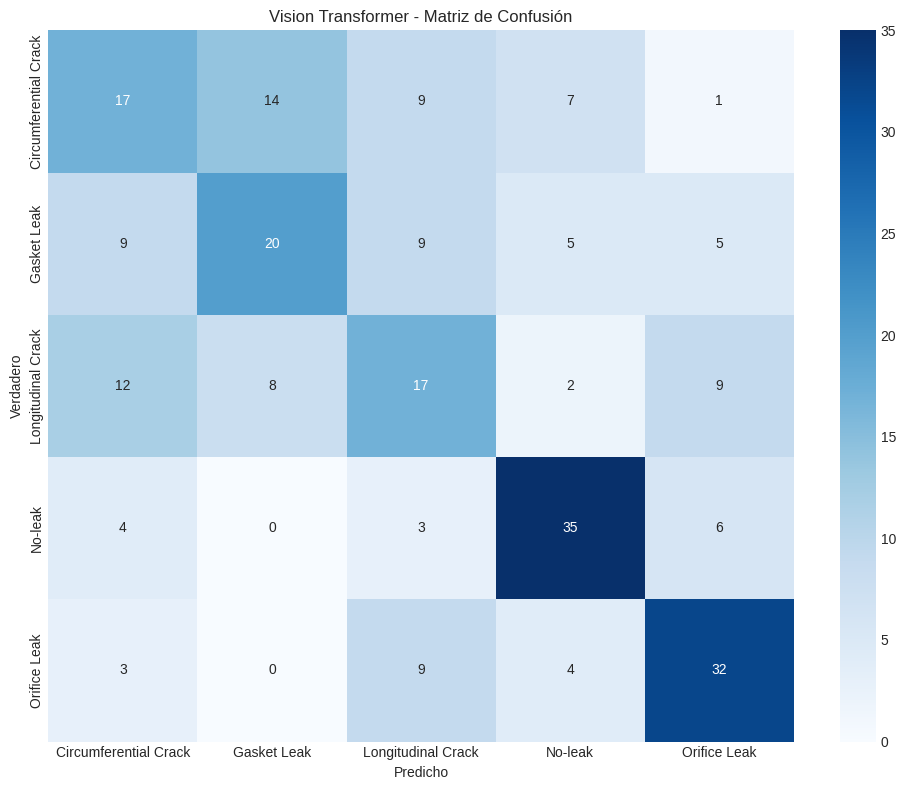

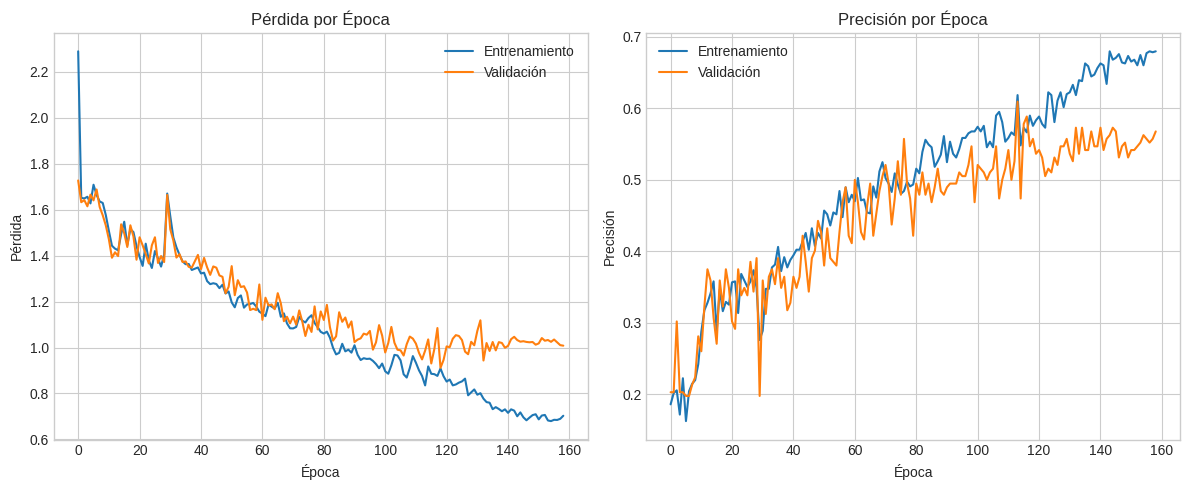


==== INFORME DETALLADO DE EVALUACIÓN ====

Modelo: Vision Transformer
- Exactitud final: 0.5042
- Tiempo de inferencia total: 1.9299 segundos
- Tiempo por muestra: 8.0413 ms

Reporte de clasificación por clase:
- Circumferential Crack: Precisión=0.3778, Recall=0.3542, F1=0.3656
- Gasket Leak: Precisión=0.4762, Recall=0.4167, F1=0.4444
- Longitudinal Crack: Precisión=0.3617, Recall=0.3542, F1=0.3579
- No-leak: Precisión=0.6604, Recall=0.7292, F1=0.6931
- Orifice Leak: Precisión=0.6038, Recall=0.6667, F1=0.6337

Promedios ponderados:
- Precisión: 0.4960
- Recall: 0.5042
- F1-Score: 0.4989

Proceso de entrenamiento y evaluación del Vision Transformer completado.


In [12]:
# Dimensiones de entrada PADDED (272, 112)
input_c = x_train_padded.shape[1]
input_h = x_train_padded.shape[2]
input_w = x_train_padded.shape[3]
input_shape_vit = (input_h, input_w) # (272, 112)

# Parámetros del ViT ajustados para ser divisibles por (272, 112):
# El parche (16, 16) es compatible con (272, 112) ya que 272/16 = 17 y 112/16 = 7.
# Usaremos los parámetros de la plantilla, pero forzaremos el parche a uno compatible.
vit_patch_size_h = 8
vit_patch_size_w = 8
vit_embed_dim = 768
vit_depth = 10
vit_num_heads = 8
vit_mlp_ratio = 4
vit_drop_rate = 0.15
vit_attn_drop_rate = 0.05

is_binary = (num_classes == 2)

print(f"Dimensiones de entrada del Espectrograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT (Ajustado): {vit_patch_size_h}x{vit_patch_size_w}")
print(f"Número de Clases: {num_classes} (Binario: {is_binary})")


# Instanciar el modelo Vision Transformer
print("\nCreando modelo Vision Transformer...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    drop_rate=vit_drop_rate,
    attn_drop_rate=vit_attn_drop_rate,
    is_binary=is_binary
).to(device)


# --- 4. Definición de la Función de Pérdida y el Optimizador ---
if is_binary:
    # BCEWithLogitsLoss es ideal para la salida lineal del head (1 neurona)
    criterion = nn.BCEWithLogitsLoss()
else:
    # CrossEntropyLoss es ideal para multiclase con etiquetas long
    criterion = nn.CrossEntropyLoss()

from torch.optim import AdamW
#optimizer = Adam(vit_model.parameters(), lr=1e-5)
optimizer = AdamW(vit_model.parameters(), lr=5e-4, weight_decay=0.05)

# Imprimir resumen del modelo
print("\n--- Resumen del Modelo Vision Transformer ---")
print(f"Dimensiones de Patch Embedding (1x{vit_embed_dim}): {vit_model.patch_embed.num_patches} parches")
print(f"Número de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad) / 1e6:.2f} M")
print("------------------------------------------")
print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")

# ==============================================================================
# IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ==============================================================================
# Importaciones necesarias (asegúrate de que estén disponibles en tu entorno)
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import tqdm

# --- 0. Limpieza adicional de memoria ---
# 'wavelet_denoised_signals_dict' fue una variable temporal y se elimina si aún existe.
#print("Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...")
#if 'wavelet_denoised_signals_dict' in globals():
    #del wavelet_denoised_signals_dict
    #gc.collect()
    #print("'wavelet_denoised_signals_dict' eliminado de la memoria.")
#else:
    #print("'wavelet_denoised_signals_dict' no encontrado o ya eliminado.")

# Limpiar el resto de variables intermedias si existen
#if 'x_train' in globals():
    #del x_train, y_train, x_test, y_test, y_train_onehot, y_test_onehot
    #gc.collect()


# --- 1. Ajustar DataLoaders ---
# Asumiendo que train_loader, val_loader, test_loader, device, vit_model,
# criterion, optimizer, num_classes, is_binary YA ESTÁN DEFINIDOS.

# Ajustar num_workers a 0 para reducir el consumo de RAM, como se sugirió.
train_loader.num_workers = 0
val_loader.num_workers = 0
test_loader.num_workers = 0

# Obtener valores necesarios del entorno actual (asumiendo que existen)
# is_binary ya debe estar definido en la celda de inicialización del ViT.
# num_classes ya debe estar definido en la celda de inicialización del ViT.

# Obtener los nombres de las clases (usaremos 0 y 1 para binario si no hay un diccionario global)
if 'label_codes_dict' in globals():
    # Asumiendo que label_codes_dict está en el scope global y contiene {'Leak': 0, 'No-leak': 1}
    class_names = list(label_codes_dict.keys())
elif is_binary:
    class_names = ['Leak (0)', 'No-leak (1)']
else:
    class_names = [f'Clase {i}' for i in range(num_classes)]


print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 2. Configurar Callbacks ---
epochs = 200
patience = 40 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=min_lr)

# Model Checkpoint path (Ajusta la ruta a un lugar específico en tu Drive)
model_save_path = "/content/drive/MyDrive/STFT/ViT_Spectrogram_best_model.pt"

# Habilitar Mixed Precision Training si tu GPU lo soporta
# (Esto reducirá el consumo de VRAM y acelerará el entrenamiento)
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()


# --- 3. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    # Usar tqdm.tqdm es más robusto que solo tqdm
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        # Forward pass con Mixed Precision
        with autocast():
            outputs = vit_model(inputs)

            if is_binary:
                # Labels deben ser (BatchSize, 1) y float para BCEWithLogitsLoss
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                # Labels deben ser (BatchSize) y long para CrossEntropyLoss
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        # Backward pass y optimización con GradScaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

        # Cálculo de Accuracy
        if is_binary:
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted.squeeze(1) == labels.float()).sum().item()
        else:
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(): # Forward pass con Mixed Precision
                outputs = vit_model(inputs)

                if is_binary:
                    labels_for_loss = labels.float().unsqueeze(1)
                else:
                    labels_for_loss = labels

                loss = criterion(outputs, labels_for_loss)

            val_running_loss += loss.item() * inputs.size(0)

            # Cálculo de Accuracy
            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted.squeeze(1) == labels.float()).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"💾 Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"🛑 Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 4. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast(): # Forward pass con Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs)
            y_pred_batch = (y_prob_batch > 0.5).float()

            all_y_true.extend(labels.cpu().numpy().flatten())
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch.squeeze(1) == labels.float()).sum().item()
        else:
            _, predicted_class = torch.max(outputs.data, 1)
            probs_batch = F.softmax(outputs, dim=1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0)

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

if is_binary:
    y_pred_probs_np = np.array(all_y_pred_probs)
else:
    # Asegurar que las probabilidades tienen la forma (N, num_classes)
    y_pred_probs_np = np.array(all_y_pred_probs).reshape(-1, num_classes)


# --- 5. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True, zero_division=0)

# Create results dictionary for visualization
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc,
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show() #

# 2. Curvas ROC y Precision-Recall para clasificación binaria
if is_binary:
    y_score = resultados_vit['y_pred_probs'].flatten()

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show() #

# 3. Gráfico de Pérdida y Precisión vs Épocas
plt.figure(figsize=(12, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Entrenamiento')
plt.plot(history['val_loss'], label='Validación')
plt.title('Pérdida por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Precisión
plt.subplot(1, 2, 2)
plt.plot(history['train_accuracy'], label='Entrenamiento')
plt.plot(history['val_accuracy'], label='Validación')
plt.title('Precisión por Época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show() #


# --- 6. Imprimir métricas detalladas ---
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud final: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")
# Cleanup
# Eliminar DataLoaders y liberar memoria después de la evaluación.
#del train_loader, val_loader, test_loader
#gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

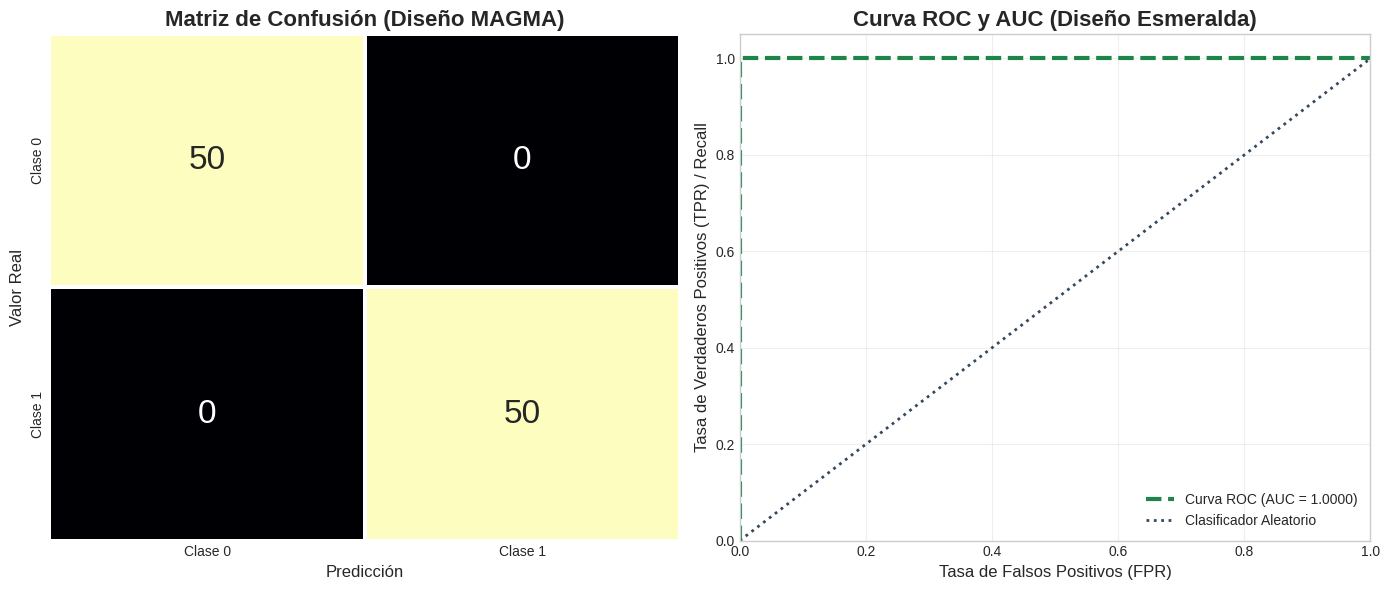

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# --- 1. Generar Datos Aleatorios para Pruebas ---
# Simular 100 etiquetas reales (50 de clase 0, 50 de clase 1)
np.random.seed(42) # Para reproducibilidad
N = 100
y_true_np = np.concatenate([np.zeros(N // 2), np.ones(N // 2)])
np.random.shuffle(y_true_np)

# Simular probabilidades predichas (un modelo con buen rendimiento)
# Las probabilidades serán altas para la clase 1 y bajas para la clase 0, con algunos errores.
y_proba_np = np.zeros_like(y_true_np, dtype=float)
y_proba_np[y_true_np == 0] = np.random.uniform(0.01, 0.45, size=(N // 2)) # Clase 0 predicha bajo 0.5
y_proba_np[y_true_np == 1] = np.random.uniform(0.55, 0.99, size=(N // 2)) # Clase 1 predicha sobre 0.5

# Simular un umbral de decisión (usaremos 0.5 para la matriz)
y_pred_standard = (y_proba_np >= 0.5).astype(int)

# --- 2. Preparar Métricas ---
# Matriz de Confusión
cm = confusion_matrix(y_true_np, y_pred_standard)

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_true_np, y_proba_np)
roc_auc = auc(fpr, tpr)


# --- 3. Personalización y Visualización ---

# Configuración de estilo global
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo limpio para el fondo
plt.figure(figsize=(14, 6))

### A. Visualización 1: Matriz de Confusión (Diseño Personalizado) ###
plt.subplot(1, 2, 1)

# Usando Seaborn para el Heatmap
sns.heatmap(
    cm,
    annot=True,            # Muestra los números en las celdas
    fmt='d',               # Formato de los números como entero
    cmap='magma',          # 👈 Paleta de color: "magma"
    linewidths=1.5,        # Líneas más gruesas
    linecolor='white',     # Color de línea blanco para contraste
    annot_kws={'fontsize': 24},
    cbar=False,            # Ocultar barra lateral de color
    xticklabels=['Clase 0', 'Clase 1'],
    yticklabels=['Clase 0', 'Clase 1']
)

plt.title('Matriz de Confusión (Diseño MAGMA)', fontsize=16, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)


### B. Visualización 2: Curva ROC (Diseño Personalizado) ###
plt.subplot(1, 2, 2)

# Curva ROC Principal
plt.plot(
    fpr, tpr,
    color='#1E8449', # 👈 Color personalizado (Verde Esmeralda)
    lw=3,             # Ancho de línea
    linestyle='--',   # Estilo de línea punteado
    label=f'Curva ROC (AUC = {roc_auc:.4f})'
)

# Línea de referencia aleatoria
plt.plot([0, 1], [0, 1], color='#34495E', lw=2, linestyle=':', label='Clasificador Aleatorio')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall', fontsize=12)
plt.title('Curva ROC y AUC (Diseño Esmeralda)', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='-', alpha=0.3) # Rejilla más visible

plt.tight_layout() # Ajustar el espacio entre gráficos
plt.show()